In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json 
%matplotlib inline 
import matplotlib
import matplotlib.pyplot as plt 
import seaborn as sns
from src import util_analysis 

# from matplotlib.ticker import FormatStrFormatter
import re 

In [ ]:
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

fig_out_dir = Path("final_figures/figure_2")
fig_out_dir.mkdir(exist_ok=True, parents=True)

## Plot results from Popham-style conditions using SWC stimuli

In [3]:
participant_df = pd.read_csv('final_results_to_share/experiment_2_df_for_plot_and_stats.csv')
participant_df = participant_df[participant_df.group.str.contains('Humans')]

In [13]:
participant_df.head(2)

,id_subject,target_harmonicity,distractor_harmonicity,attended_stream,hits,group,model
0,56259489ed6e5a0005c80fde,Harmonic,Harmonic,Target,0.933333,Humans (N = 90),NaN
1,56259489ed6e5a0005c80fde,Harmonic,Inharmonic,Target,0.466667,Humans (N = 90),NaN


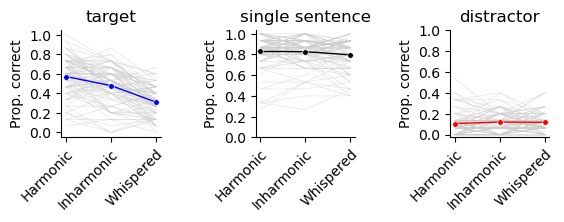

In [17]:
to_plot = participant_df[(participant_df.target_harmonicity == participant_df.distractor_harmonicity) | (participant_df.distractor_harmonicity == 'No Distractor')]

no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 
to_plot = to_plot[to_plot.distractor_harmonicity != 'No Distractor']

hues = ['k', 'b', 'r']
hue_order = ['Single sentence', 'Target', 'Distractor']

palette = {'Target': 'b', 'Distractor': 'r', 'Single sentence': 'k'}

fontsize=10
tick_fontsize = 10
# fontsize = 10
err_band_alpha = 0.2

yticks = np.linspace(0,1,6).round(1)

xtick_labels = to_plot.distractor_harmonicity.unique()
xticks = np.arange(len(xtick_labels))
ratio = 1.0 
line_thickness = 1
# n_conditions = to_plot.target_harmonicity.nunique()
# aspect = 2
# fig, axs = plt.subplots(1, n_conditions, figsize=((aspect) * (n_conditions + .5), aspect ))


g = sns.relplot(
    data=to_plot,
    x="distractor_harmonicity",
    y="hits",
    col="attended_stream",
    # col_order=col_order,
    hue="attended_stream",
    palette=palette,  #hue_order=hue_order,
    kind="line",
    zorder=4, #human_data
    marker='.', 
    markersize=8,
    markeredgewidth=.4,
    linewidth=1,
    errorbar=None,#("se", 1), 
    facet_kws={'sharex': False,
               'sharey': False},
    # col_wrap=4,
    height=2,
    aspect=1,
    legend=False,
)


for attended_stream, ax in g.axes_dict.items():
    sns.lineplot(
        data=to_plot[to_plot.attended_stream==attended_stream],
        x="distractor_harmonicity",
        y="hits",
        units="id_subject",
        estimator=None, 
        color=".8",
        linewidth=0.5,
        zorder=1,
        alpha=0.5,
        ax=ax,
    )

g.set_titles("{col_name}")
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.lower())

# rotate xtick labels
for ax in g.axes.flat:
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=tick_fontsize)
    ax.set_xlabel('', fontsize=fontsize)
    ax.set_ylabel('Prop. correct', fontsize=fontsize)
    # ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    # ax.set_ylim([0, 1])
    # ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=tick_fontsize)
